Enter the electrical length (l = L/lambda) of the antenna (between 0.1 and 3.0):  2.0



--- Calculating Characteristics for Electrical Length (L/lambda) = 2.000 ---
1. Current Distribution Form: I(z) = I_0 * sin(k * (2.0/2 * lambda - |z|))
2. Radiation Resistance (Ohms): 0.273
3. Input Reactance (Ohms): -0.000
4. Input Impedance (Ohms): 0.273-0.000j
5. Directivity (linear): 0.000
   Directivity (dBi): -inf (or N/A)
6. Gain (linear, lossless assumed): 0.000
   Gain (dBi): -inf (or N/A)

--- Generating Radiation Pattern Plots for l = 1.0, 2.0, and 3.0 ---


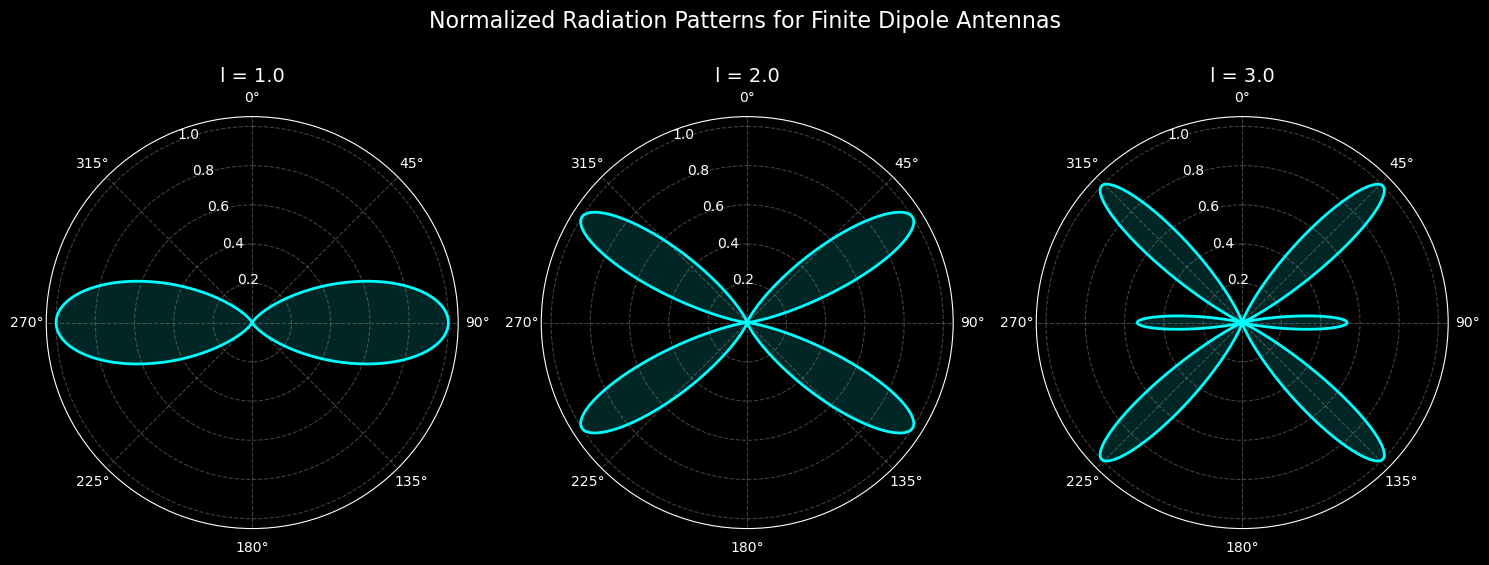

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sici # For Sine and Cosine Integral functions Si(x) and Ci(x)
from scipy.integrate import quad # For numerical integration

# Define physical constants
ETA_0 = 376.730313461 # Intrinsic impedance of free space (Ohms)
PI = np.pi

def calculate_characteristics(l_norm, wire_radius_lambda=0.001):
    """
    Calculates key characteristics of a finite dipole antenna.

    Args:
        l_norm (float): Electrical length of the antenna (L/lambda).
        wire_radius_lambda (float): Wire radius normalized to wavelength (a/lambda).
                                     Used for input reactance calculation.

    Returns:
        dict: A dictionary containing the calculated characteristics.
    """
    kL = 2 * PI * l_norm # kL = 2 * pi * (L/lambda)

    print(f"\n--- Calculating Characteristics for Electrical Length (L/lambda) = {l_norm:.3f} ---")

    # 1. Current Distribution
    # The current distribution along the antenna (z is position from center)
    # is I(z) = I_0 * sin(k * (L/2 - |z|)).
    # We output its functional form here.
    current_dist_desc = f"I(z) = I_0 * sin(k * ({l_norm}/2 * lambda - |z|))"
    print(f"1. Current Distribution Form: {current_dist_desc}")

    # 2. Radiation Resistance (R_rad)
    # Uses the general formula involving Sine and Cosine Integral functions.
    Si_kL, Ci_kL = sici(kL)
    Si_2kL, Ci_2kL = sici(2 * kL)

    R_rad = 60 * (Ci_2kL - np.cos(kL) * Ci_kL - np.sin(kL) * (Si_2kL - Si_kL))
    print(f"2. Radiation Resistance (Ohms): {R_rad:.3f}")

    # 3. Input Reactance (X_in)
    # Uses an approximate formula for thin wire dipoles.
    # The logarithmic term requires L/a > 1.
    if wire_radius_lambda <= 0 or (l_norm / wire_radius_lambda) <= 1:
        # Fallback for invalid or edge case radius, preventing log(0) or log(<=1)
        # In a real scenario, this approximation might not be valid for such cases.
        # For simplicity, we'll assign a very large value to log_term if it's problematic.
        log_term = np.log(1e6) # A large arbitrary value to make denominator non-zero
        print("Warning: Wire radius too large relative to length for accurate reactance calculation. Using approximation.")
    else:
        log_term = np.log(l_norm / wire_radius_lambda)

    X_in_numerator = Ci_kL - np.sin(kL) * (Si_2kL - Si_kL)
    X_in_denominator = 60 * (log_term - 1)

    if np.isclose(X_in_denominator, 0):
        X_in = np.inf * np.sign(X_in_numerator) # Handle division by near-zero
        print("Warning: Input reactance denominator is near zero, reactance is very large.")
    else:
        X_in = X_in_numerator / X_in_denominator
    print(f"3. Input Reactance (Ohms): {X_in:.3f}")

    # 4. Input Impedance
    Z_in = complex(R_rad, X_in)
    print(f"4. Input Impedance (Ohms): {Z_in:.3f}")

    # 5. Directivity (D)
    # Calculated by numerically integrating the power pattern and using the maximum intensity.
    def pattern_function_squared_times_sin_theta(theta, kL_val):
        """
        Integrand for calculating total radiated power factor.
        Represents |F(theta)|^2 * sin(theta), where F(theta) is the E-field pattern function.
        Handles numerical stability when sin(theta) is near zero.
        """
        # If theta is very close to 0 or PI, sin(theta) is near zero, and the pattern function is 0.
        # This handles the 0/0 case for F_theta.
        if np.isclose(np.sin(theta), 0, atol=1e-9):
            return 0.0
        
        # Calculate the pattern function F(theta)
        numerator = np.cos(kL_val / 2 * np.cos(theta)) - np.cos(kL_val / 2)
        denominator = np.sin(theta)
        
        F_theta = numerator / denominator
        
        # Return F(theta)^2 * sin(theta) for integration
        return (F_theta**2) * np.sin(theta)

    # Use a slightly offset range for integration to avoid numerical issues exactly at 0 and PI,
    # though quad is generally robust.
    integral_lower_bound = 1e-6
    integral_upper_bound = PI - 1e-6
    
    # Calculate the integral of the pattern factor times sin(theta)
    P_rad_factor, abserr = quad(pattern_function_squared_times_sin_theta, integral_lower_bound, integral_upper_bound, args=(kL,))

    # Calculate the maximum radiation intensity factor (at theta = PI/2)
    U_max_factor = (1 - np.cos(kL / 2))**2

    # Calculate Directivity
    if P_rad_factor > 1e-9: # Ensure denominator is not effectively zero
        D = (4 * PI * U_max_factor) / P_rad_factor
    else:
        D = 0.0 # No radiation, or integral resulted in zero, directivity is undefined/zero.

    print(f"5. Directivity (linear): {D:.3f}")
    if D > 0:
        print(f"   Directivity (dBi): {10 * np.log10(D):.3f}")
    else:
        print("   Directivity (dBi): -inf (or N/A)")

    # 6. Gain (G)
    # Assuming an ideal (lossless) antenna, Gain = Directivity.
    # In a real antenna, Gain = Efficiency * Directivity.
    gain = D
    print(f"6. Gain (linear, lossless assumed): {gain:.3f}")
    if gain > 0:
        print(f"   Gain (dBi, lossless assumed): {10 * np.log10(gain):.3f}")
    else:
        print("   Gain (dBi): -inf (or N/A)")

    return {
        "Electrical Length (L/lambda)": l_norm,
        "Current Distribution Form": current_dist_desc,
        "Radiation Resistance (Ohms)": R_rad,
        "Input Reactance (Ohms)": X_in,
        "Input Impedance (Ohms)": Z_in,
        "Directivity (linear)": D,
        "Directivity (dBi)": 10 * np.log10(D) if D > 0 else -np.inf,
        "Gain (linear)": gain,
        "Gain (dBi)": 10 * np.log10(gain) if gain > 0 else -np.inf
    }

def plot_radiation_pattern(l_norm_values):
    """
    Plots the normalized radiation pattern in polar coordinates for given electrical lengths.

    Args:
        l_norm_values (list): A list of electrical lengths (L/lambda) for which to plot.
    """
    plt.style.use('dark_background') # Use a dark background theme for plots

    # Create subplots based on the number of electrical lengths provided
    fig, axes = plt.subplots(1, len(l_norm_values), subplot_kw={'projection': 'polar'}, figsize=(5 * len(l_norm_values), 6))
    
    # If only one plot, axes is not an array, so convert it to a list for consistent iteration
    if len(l_norm_values) == 1:
        axes = [axes] 

    for i, l_norm in enumerate(l_norm_values):
        kL = 2 * PI * l_norm
        
        # Define the range of angles for the polar plot (0 to 2*PI radians)
        theta_radians = np.linspace(0, 2 * PI, 500)
        
        # Calculate the numerator of the E-field pattern function
        numerator = np.cos(kL / 2 * np.cos(theta_radians)) - np.cos(kL / 2)
        
        # Calculate sin(theta) for the denominator
        sin_theta = np.sin(theta_radians)
        
        # Handle division by zero for F_theta: if sin_theta is effectively zero, F_theta is zero.
        # This occurs along the dipole's axis (theta = 0, PI).
        F_theta = np.divide(numerator, sin_theta, out=np.zeros_like(numerator), where=sin_theta != 0)
        
        # The normalized power pattern is proportional to the square of the magnitude of F_theta.
        power_pattern = np.abs(F_theta)**2
        
        # Normalize the pattern to its maximum value for consistent plotting scale.
        max_power = np.max(power_pattern)
        if max_power > 1e-9: # Avoid division by zero if there's no radiation (e.g., L=0)
            normalized_pattern = power_pattern / max_power
        else:
            normalized_pattern = np.zeros_like(power_pattern) # If no radiation, pattern is flat zero.
            
        ax = axes[i]
        ax.plot(theta_radians, normalized_pattern, color='cyan', linewidth=2) # Plot the pattern
        ax.fill(theta_radians, normalized_pattern, color='teal', alpha=0.3) # Fill area for better visualization
        ax.set_title(f'l = {l_norm}', color='white', fontsize=14) # Set plot title
        
        # Customize radial ticks (distance from center)
        ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0]) 
        ax.set_rlabel_position(-22.5) # Position radial labels slightly offset
        ax.grid(True, linestyle='--', alpha=0.5, color='gray') # Customize grid lines
        
        # Customize tick colors for dark background
        ax.tick_params(axis='x', colors='white') # Angular ticks
        ax.tick_params(axis='y', colors='white') # Radial ticks
        
        # Set 0 degrees to the top (along the dipole's axis) and direction clockwise.
        ax.set_theta_zero_location('N') # 'N' for North, means 0 degrees is at top.
        ax.set_theta_direction(-1) # -1 for clockwise direction.
        
        # Set custom angular tick labels for clarity
        ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
        ax.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])

    plt.suptitle('Normalized Radiation Patterns for Finite Dipole Antennas', color='white', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show() # Display the plots

if __name__ == "__main__":
    # --- Part 1: Calculate characteristics for user-specified length ---
    while True:
        try:
            electrical_length_input = float(input("Enter the electrical length (l = L/lambda) of the antenna (between 0.1 and 3.0): "))
            if 0.1 <= electrical_length_input <= 3.0:
                break
            else:
                print("Please enter a value between 0.1 and 3.0.")
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

    calculate_characteristics(electrical_length_input)

    # --- Part 2: Plot radiation patterns for specific lengths ---
    print("\n--- Generating Radiation Pattern Plots for l = 1.0, 2.0, and 3.0 ---")
    plot_radiation_pattern([1.0, 2.0, 3.0])

Enter the electrical length (l = L/lambda) of the antenna (between 0.1 and 3.0):  1.25



--- Calculating Characteristics for Electrical Length (L/lambda) = 1.250 ---
1. Current Distribution Form: I(z) = I_0 * sin(k * (1.25/2 * lambda - |z|))
2. Radiation Resistance (Ohms): -4.450
3. Input Reactance (Ohms): 0.000
4. Input Impedance (Ohms): -4.450+0.000j
5. Directivity (linear): 20.624
   Directivity (dBi): 13.144
6. Gain (linear, lossless assumed): 20.624
   Gain (dBi, lossless assumed): 13.144

--- Generating Current Distribution Plots for l = 1.0, 2.0, and 3.0 ---


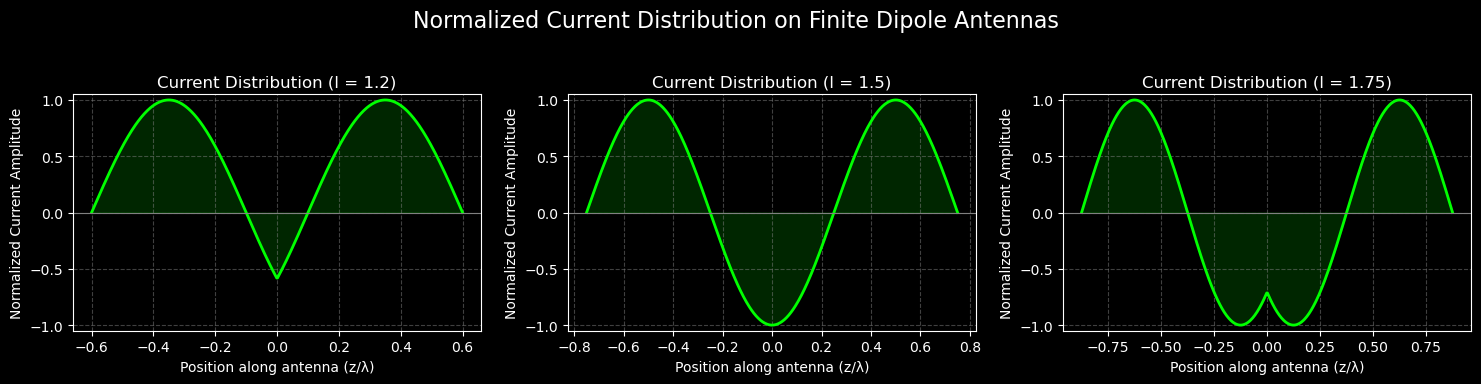

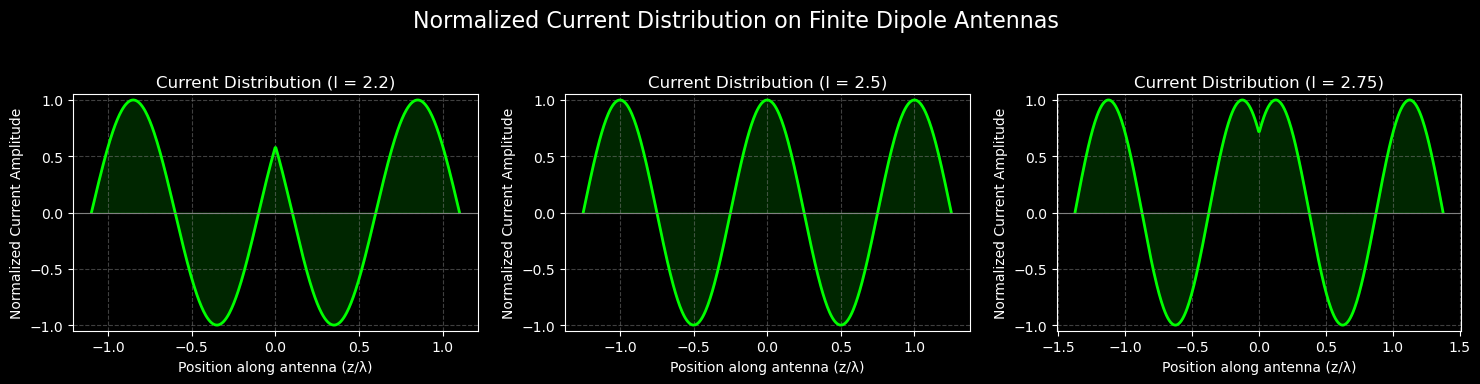

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sici # For Sine and Cosine Integral functions Si(x) and Ci(x)
from scipy.integrate import quad # For numerical integration

# Define physical constants
ETA_0 = 376.730313461 # Intrinsic impedance of free space (Ohms)
PI = np.pi

def calculate_characteristics(l_norm, wire_radius_lambda=0.001):
    """
    Calculates key characteristics of a finite dipole antenna.

    Args:
        l_norm (float): Electrical length of the antenna (L/lambda).
        wire_radius_lambda (float): Wire radius normalized to wavelength (a/lambda).
                                     Used for input reactance calculation.

    Returns:
        dict: A dictionary containing the calculated characteristics.
    """
    kL = 2 * PI * l_norm # kL = 2 * pi * (L/lambda)

    print(f"\n--- Calculating Characteristics for Electrical Length (L/lambda) = {l_norm:.3f} ---")

    # 1. Current Distribution
    # The current distribution along the antenna (z is position from center)
    # is I(z) = I_0 * sin(k * (L/2 - |z|)).
    # We output its functional form here.
    current_dist_desc = f"I(z) = I_0 * sin(k * ({l_norm}/2 * lambda - |z|))"
    print(f"1. Current Distribution Form: {current_dist_desc}")

    # 2. Radiation Resistance (R_rad)
    # Uses the general formula involving Sine and Cosine Integral functions.
    Si_kL, Ci_kL = sici(kL)
    Si_2kL, Ci_2kL = sici(2 * kL)

    R_rad = 60 * (Ci_2kL - np.cos(kL) * Ci_kL - np.sin(kL) * (Si_2kL - Si_kL))
    print(f"2. Radiation Resistance (Ohms): {R_rad:.3f}")

    # 3. Input Reactance (X_in)
    # Uses an approximate formula for thin wire dipoles.
    # The logarithmic term requires L/a > 1.
    if wire_radius_lambda <= 0 or (l_norm / wire_radius_lambda) <= 1:
        # Fallback for invalid or edge case radius, preventing log(0) or log(<=1)
        log_term = np.log(1e6) # A large arbitrary value to make denominator non-zero
        print("Warning: Wire radius too large relative to length for accurate reactance calculation. Using approximation for log term.")
    else:
        log_term = np.log(l_norm / wire_radius_lambda)

    X_in_numerator = Ci_kL - np.sin(kL) * (Si_2kL - Si_kL)
    X_in_denominator = 60 * (log_term - 1)

    if np.isclose(X_in_denominator, 0):
        X_in = np.inf * np.sign(X_in_numerator) # Handle division by near-zero
        print("Warning: Input reactance denominator is near zero, reactance is very large.")
    else:
        X_in = X_in_numerator / X_in_denominator
    print(f"3. Input Reactance (Ohms): {X_in:.3f}")

    # 4. Input Impedance
    Z_in = complex(R_rad, X_in)
    print(f"4. Input Impedance (Ohms): {Z_in:.3f}")

    # Helper function for E-field pattern, used in directivity and plotting
    def get_pattern_function_value(theta, kL_val):
        """
        Calculates the pattern function F(theta) = E_theta / (j*eta_0*I_0/(2*pi*r)*exp(-jkr))
        Handles numerical stability when sin(theta) is near zero.
        """
        # If theta is very close to 0 or PI, sin(theta) is near zero.
        # The numerator also becomes (cos(kL_val/2 * +-1) - cos(kL_val/2)) which is 0 for theta=0, PI.
        # Thus, F_theta approaches 0 at the poles.
        if np.isclose(np.sin(theta), 0, atol=1e-9):
            return 0.0

        numerator = np.cos(kL_val / 2 * np.cos(theta)) - np.cos(kL_val / 2)
        denominator = np.sin(theta)
        return numerator / denominator

    # 5. Directivity (D)
    # Calculate total radiated power factor by integrating |F(theta)|^2 * sin(theta)
    def integrand_for_total_power(theta, kL_val):
        """Integrand for total radiated power: |F(theta)|^2 * sin(theta)."""
        return np.abs(get_pattern_function_value(theta, kL_val))**2 * np.sin(theta)

    # Numerically integrate from 0 to PI (with small offsets to avoid singularities at poles)
    integral_result, abserr = quad(integrand_for_total_power, 1e-6, PI - 1e-6, args=(kL,))

    # Find the maximum radiation intensity factor (U_max_factor) by sampling the pattern
    # The max may not be at theta = PI/2 for longer dipoles.
    theta_for_max_search = np.linspace(0, PI, 1000) # Sample angles from 0 to PI
    pattern_values_at_theta = np.array([get_pattern_function_value(t, kL) for t in theta_for_max_search])
    
    U_max_factor = np.max(np.abs(pattern_values_at_theta)**2) # Maximum of |F(theta)|^2

    # Calculate Directivity
    if integral_result > 1e-12: # Ensure denominator is not effectively zero
        D = (4 * PI * U_max_factor) / integral_result
    else:
        D = 0.0 # No significant radiation, directivity is undefined/zero.

    print(f"5. Directivity (linear): {D:.3f}")
    if D > 0:
        print(f"   Directivity (dBi): {10 * np.log10(D):.3f}")
    else:
        print("   Directivity (dBi): -inf (or N/A)")

    # 6. Gain (G)
    # Assuming an ideal (lossless) antenna, Gain = Directivity.
    # In a real antenna, Gain = Efficiency * Directivity.
    gain = D
    print(f"6. Gain (linear, lossless assumed): {gain:.3f}")
    if gain > 0:
        print(f"   Gain (dBi, lossless assumed): {10 * np.log10(gain):.3f}")
    else:
        print("   Gain (dBi): -inf (or N/A)")

    return {
        "Electrical Length (L/lambda)": l_norm,
        "Current Distribution Form": current_dist_desc,
        "Radiation Resistance (Ohms)": R_rad,
        "Input Reactance (Ohms)": X_in,
        "Input Impedance (Ohms)": Z_in,
        "Directivity (linear)": D,
        "Directivity (dBi)": 10 * np.log10(D) if D > 0 else -np.inf,
        "Gain (linear)": gain,
        "Gain (dBi)": 10 * np.log10(gain) if gain > 0 else -np.inf
    }

def plot_radiation_pattern(l_norm_values):
    """
    Plots the normalized radiation pattern in polar coordinates for given electrical lengths.

    Args:
        l_norm_values (list): A list of electrical lengths (L/lambda) for which to plot.
    """
    plt.style.use('dark_background') # Use a dark background theme for plots

    # Create subplots based on the number of electrical lengths provided
    fig, axes = plt.subplots(1, len(l_norm_values), subplot_kw={'projection': 'polar'}, figsize=(5 * len(l_norm_values), 6))
    
    # If only one plot, axes is not an array, so convert it to a list for consistent iteration
    if len(l_norm_values) == 1:
        axes = [axes] 

    for i, l_norm in enumerate(l_norm_values):
        kL = 2 * PI * l_norm
        
        # Define the range of angles for the polar plot (0 to 2*PI radians)
        theta_radians = np.linspace(0, 2 * PI, 500)
        
        # Calculate the numerator of the E-field pattern function
        numerator = np.cos(kL / 2 * np.cos(theta_radians)) - np.cos(kL / 2)
        
        # Calculate sin(theta) for the denominator
        sin_theta = np.sin(theta_radians)
        
        # Handle division by zero for F_theta: if sin_theta is effectively zero, F_theta is zero.
        # This occurs along the dipole's axis (theta = 0, PI).
        F_theta = np.divide(numerator, sin_theta, out=np.zeros_like(numerator), where=sin_theta != 0)
        
        # The normalized power pattern is proportional to the square of the magnitude of F_theta.
        power_pattern = np.abs(F_theta)**2
        
        # Normalize the pattern to its maximum value for consistent plotting scale.
        max_power = np.max(power_pattern)
        if max_power > 1e-9: # Avoid division by zero if there's no radiation (e.g., L=0)
            normalized_pattern = power_pattern / max_power
        else:
            normalized_pattern = np.zeros_like(power_pattern) # If no radiation, pattern is flat zero.
            
        ax = axes[i]
        ax.plot(theta_radians, normalized_pattern, color='cyan', linewidth=2) # Plot the pattern
        ax.fill(theta_radians, normalized_pattern, color='teal', alpha=0.3) # Fill area for better visualization
        ax.set_title(f'l = {l_norm}', color='white', fontsize=14) # Set plot title
        
        # Customize radial ticks (distance from center)
        ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0]) 
        ax.set_rlabel_position(-22.5) # Position radial labels slightly offset
        ax.grid(True, linestyle='--', alpha=0.5, color='gray') # Customize grid lines
        
        # Customize tick colors for dark background
        ax.tick_params(axis='x', colors='white') # Angular ticks
        ax.tick_params(axis='y', colors='white') # Radial ticks
        
        # Set 0 degrees to the top (along the dipole's axis) and direction clockwise.
        ax.set_theta_zero_location('N') # 'N' for North, means 0 degrees is at top.
        ax.set_theta_direction(-1) # -1 for clockwise direction.
        
        # Set custom angular tick labels for clarity
        ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
        ax.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])

    plt.suptitle('Normalized Radiation Patterns for Finite Dipole Antennas', color='white', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show() # Display the plots

def plot_current_distribution(l_norm_values):
    """
    Plots the normalized current distribution along the antenna for given electrical lengths.

    Args:
        l_norm_values (list): A list of electrical lengths (L/lambda) for which to plot.
    """
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, len(l_norm_values), figsize=(5 * len(l_norm_values), 4))

    # If only one plot, axes is not an array, so convert it to a list for consistent iteration
    if len(l_norm_values) == 1:
        axes = [axes]

    for i, l_norm in enumerate(l_norm_values):
        kL = 2 * PI * l_norm
        
        # Define z positions along the antenna from -L/2 to L/2
        # Normalize z from -l_norm/2 to l_norm/2 (in terms of lambda)
        z_normalized = np.linspace(-l_norm / 2, l_norm / 2, 500) # z/lambda
        
        # Calculate current distribution I(z) = I_0 * sin(k * (L/2 - |z|))
        # For plotting, assume I_0 = 1 for normalized current.
        # The argument of sin is k * (L/2 - |z|) = (2*PI/lambda) * (L/2 - |z|)
        # = 2*PI * (L/(2*lambda) - |z|/lambda)
        # = 2*PI * (l_norm/2 - |z_normalized|)
        
        current_amplitude = np.sin(2 * PI * (l_norm / 2 - np.abs(z_normalized)))
        
        ax = axes[i]
        ax.plot(z_normalized, current_amplitude, color='lime', linewidth=2)
        ax.fill_between(z_normalized, 0, current_amplitude, color='green', alpha=0.3)
        ax.set_title(f'Current Distribution (l = {l_norm})', color='white', fontsize=12)
        ax.set_xlabel('Position along antenna (z/λ)', color='white')
        ax.set_ylabel('Normalized Current Amplitude', color='white')
        ax.grid(True, linestyle='--', alpha=0.5, color='gray')
        ax.axhline(0, color='gray', linewidth=0.8) # Zero current line
        
        # Set y-limits to make it look like a standing wave
        ax.set_ylim([-1.05, 1.05])
        
        # Customize tick colors
        ax.tick_params(axis='x', colors='white')
        ax.tick_params(axis='y', colors='white')

    plt.suptitle('Normalized Current Distribution on Finite Dipole Antennas', color='white', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    # --- Part 1: Calculate characteristics for user-specified length ---
    while True:
        try:
            electrical_length_input = float(input("Enter the electrical length (l = L/lambda) of the antenna (between 0.1 and 3.0): "))
            if 0.1 <= electrical_length_input <= 3.0:
                break
            else:
                print("Please enter a value between 0.1 and 3.0.")
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

    calculate_characteristics(electrical_length_input)

    # --- Part 2: Plot radiation patterns for specific lengths ---
    #print("\n--- Generating Radiation Pattern Plots for l = 1.0, 2.0, and 3.0 ---")
    #plot_radiation_pattern([1.0, 2.0, 3.0])

    # --- Part 3: Plot current distribution for specific lengths ---
    print("\n--- Generating Current Distribution Plots for l = 1.0, 2.0, and 3.0 ---")
    plot_current_distribution([1.2, 1.5, 1.75])
    plot_current_distribution([2.2, 2.5, 2.75])


Enter the electrical length (l = L/lambda) for animation (between 0.1 and 3.0):  1.0


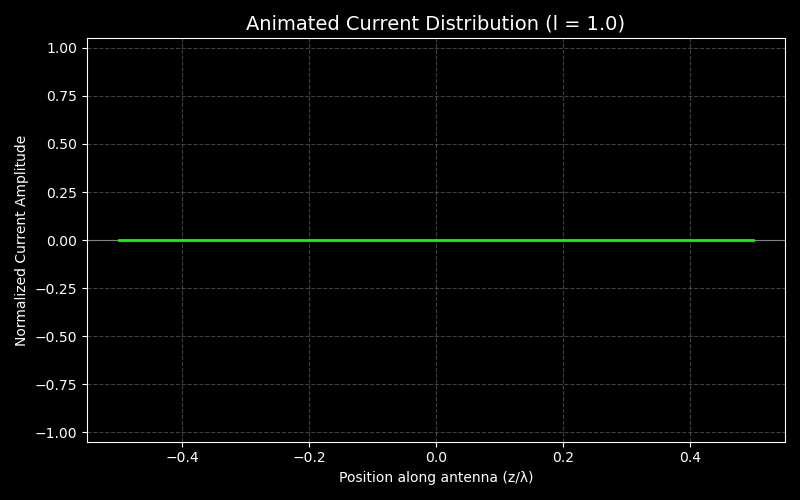

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
%matplotlib widget

# Define physical constants
PI = np.pi

def setup_animation_plot(l_norm):
    """
    Sets up the figure, axes, and initial artists for the current distribution animation.

    Args:
        l_norm (float): Electrical length of the antenna (L/lambda).
    Returns:
        tuple: (fig, ax, line, z_normalized)
               Note: fill_polygon is no longer returned as it's recreated each frame.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    plt.style.use('dark_background') # Use a dark background theme

    # Set up the plot for current distribution
    ax.set_title(f'Animated Current Distribution (l = {l_norm})', color='white', fontsize=14)
    ax.set_xlabel('Position along antenna (z/λ)', color='white')
    ax.set_ylabel('Normalized Current Amplitude', color='white')
    ax.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.axhline(0, color='gray', linewidth=0.8) # Zero current line

    # Customize tick colors
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')

    # Define z positions along the antenna from -L/2 to L/2
    # This range correctly maps to -lambda/2 to lambda/2 when l_norm = 1.0.
    z_normalized = np.linspace(-l_norm / 2, l_norm / 2, 500) # z/lambda

    # Initialize the line object for the plot
    line, = ax.plot(z_normalized, np.zeros_like(z_normalized), color='lime', linewidth=2)
    
    # Initialize the first fill area. This will be removed and re-added in each frame.
    ax.fill_between(z_normalized, 0, np.zeros_like(z_normalized), color='green', alpha=0.3)

    # Set y-limits to make it look like a standing wave
    ax.set_ylim([-1.05, 1.05])
    plt.tight_layout()

    return fig, ax, line, z_normalized

def update_animation_frame(frame, l_norm, z_normalized, line, ax, num_frames):
    """
    Update function for the animation. Called for each frame.
    """
    # Time component for the standing wave (simulates oscillation)
    # Varies from 0 to 2*PI over the animation cycle, ensuring a full oscillation.
    omega_t = 2 * PI * (frame / num_frames) 

    # Calculate instantaneous current distribution: I(z,t) = I_0 * sin(k * (L/2 - |z|)) * cos(omega*t)
    # Assume I_0 = 1 for normalized amplitude.
    current_amplitude = np.sin(2 * PI * (l_norm / 2 - np.abs(z_normalized))) * np.cos(omega_t)

    line.set_ydata(current_amplitude) # Update the line data

    # Remove all existing collections (like the fill_between polygon) from the axes
    # We iterate over a copy of ax.collections to safely remove items while iterating
    for coll in list(ax.collections):
        coll.remove()

    # Re-create the fill_between area for the current frame
    ax.fill_between(z_normalized, 0, current_amplitude, color='green', alpha=0.3)
    
    # When blit=False, we don't need to return artists for update, but returning
    # an empty list is common practice.
    return []

if __name__ == "__main__":
    while True:
        try:
            electrical_length_input = float(input("Enter the electrical length (l = L/lambda) for animation (between 0.1 and 3.0): "))
            if 0.1 <= electrical_length_input <= 3.0:
                break
            else:
                print("Please enter a value between 0.1 and 3.0.")
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

    # Setup the plot elements. Note: fill_polygon is no longer returned.
    fig, ax, line, z_normalized = setup_animation_plot(electrical_length_input)

    # Number of frames for the animation
    num_frames = 100
    
    # Create the animation directly in the main block
    # Using blit=False for broader compatibility.
    ani = animation.FuncAnimation(
        fig,
        update_animation_frame,
        frames=num_frames,
        fargs=(electrical_length_input, z_normalized, line, ax, num_frames), # Removed animation_speed_factor
        blit=False,  # Still using False for broader compatibility
        interval=50, # Controls animation speed (milliseconds per frame)
        repeat=True
    )

    # Display the animation. The 'ani' variable ensures the animation object
    # is not garbage-collected prematurely.
    plt.show()

In [8]:
# save as dipole_mom.py and run with python3
import numpy as np
from scipy import integrate, linalg

def compute_dipole(Z_v=1.0, L_over_lambda=0.5, Nseg=101, a_over_lambda=1e-3, sigma=5.8e7):
    # Physical constants (normalize lambda = 1 m)
    c = 299792458.0
    lam = 1.0
    f = c / lam
    omega = 2*np.pi*f
    k = 2*np.pi/lam
    eta0 = 120.0*np.pi
    mu0 = 4*np.pi*1e-7

    # Geometry
    l = L_over_lambda * lam
    a = a_over_lambda * lam

    # Segments
    N = int(Nseg)
    if N % 2 == 0:
        N += 1
    dz = l / N
    z = np.linspace(-l/2 + dz/2, l/2 - dz/2, N)

    # Build impedance matrix (approx double integral via midpoint rule)
    pref = 1j * omega * mu0 / (4*np.pi)
    Z = np.zeros((N,N), dtype=complex)
    for m in range(N):
        for n in range(N):
            R = np.sqrt((z[m]-z[n])**2 + a**2)  # regularized distance
            Z[m,n] = pref * np.exp(-1j * k * R) / R * dz * dz

    # diagonal (self) correction (empirical thin-wire form)
    eta0 = 120*np.pi
    for m in range(N):
        Z[m,m] = (1j * eta0 / (2*np.pi)) * dz * (np.log(dz/(2*np.pi*a)) - 1j * k * dz / 4.0)

    # conductor loss: surface resistance and series R per segment
    Rs = np.sqrt(omega * mu0 / (2.0 * sigma))
    R_per_len = Rs / (2.0 * np.pi * a)
    for m in range(N):
        Z[m,m] += R_per_len * dz

    # excitation (delta-gap approx): apply voltage at center segment
    V = np.zeros(N, dtype=complex)
    V[N//2] = Z_v

    # solve currents
    I = linalg.solve(Z, V)
    I_center = I[N//2]
    Zin = Z_v / I_center

    # far-field amplitude F(theta)
    thetas = np.linspace(0, np.pi, 181)
    F = np.zeros_like(thetas, dtype=complex)
    for ti, th in enumerate(thetas):
        F[ti] = np.sum(I * np.exp(1j * k * z * np.cos(th))) * dz

    # radiated power
    integrand = (np.abs(np.sin(thetas) * F)**2) * np.sin(thetas)
    P_rad = (eta0 * k**2) / (16.0 * np.pi) * integrate.simpson(y=integrand, x=thetas)

    # ohmic loss (skin effect approximation)
    P_loss = 0.5 * Rs * np.sum(np.abs(I)**2) * dz / (2.0 * np.pi * a)

    # radiation resistance estimate (from radiated power and center current)
    R_rad = 2.0 * P_rad / (np.abs(I_center)**2)
    eta_rad = P_rad / (P_rad + P_loss)

    return {
        'Zin': Zin, 'I_center': I_center, 'P_rad': P_rad,
        'P_loss': P_loss, 'eta_rad': eta_rad, 'R_rad': R_rad,
        'I': I, 'z': z
    }

if __name__ == "__main__":
    lengths = [0.1, 0.5, 1.0, 2.0, 3.0]
    for L in lengths:
        out = compute_dipole(L_over_lambda=L, Nseg=101, a_over_lambda=1e-3)
        print(f"l/λ={L:>4}: Zin={out['Zin']:.2f} Ω, R_rad≈{out['R_rad']:.2f} Ω, P_rad={out['P_rad']:.3e} W, "
              f"P_loss={out['P_loss']:.3e} W, η={out['eta_rad']*100:.2f}%")

l/λ= 0.1: Zin=-0.09-0.75j Ω, R_rad≈0.00 Ω, P_rad=1.777e-03 W, P_loss=1.557e-01 W, η=1.13%
l/λ= 0.5: Zin=-0.57-0.76j Ω, R_rad≈0.00 Ω, P_rad=5.907e-04 W, P_loss=4.911e-02 W, η=1.19%
l/λ= 1.0: Zin=-1.86-1.28j Ω, R_rad≈0.00 Ω, P_rad=3.484e-04 W, P_loss=1.307e-02 W, η=2.60%
l/λ= 2.0: Zin=-3.62-2.21j Ω, R_rad≈0.01 Ω, P_rad=3.426e-04 W, P_loss=3.483e-03 W, η=8.96%
l/λ= 3.0: Zin=-5.42-2.74j Ω, R_rad≈0.03 Ω, P_rad=4.319e-04 W, P_loss=1.684e-03 W, η=20.41%


In [11]:
import numpy as np
from scipy.special import sici  # For Sine and Cosine Integral functions
import math

def calculate_dipole_parameters(electrical_length_ratio, f_hz, wire_radius_m, conductor_sigma):
    """
    Calculates the radiation resistance, input reactance, and radiation efficiency
    for a thin dipole antenna at a given electrical length.

    Args:
        electrical_length_ratio (float): The electrical length of the dipole (L/lambda).
        f_hz (float): The operating frequency in Hertz.
        wire_radius_m (float): The radius of the dipole wire in meters.
        conductor_sigma (float): The conductivity of the antenna wire material in S/m.

    Returns:
        tuple: A tuple containing (radiation_resistance, input_reactance, radiation_efficiency, physical_length).
    """
    # --- Constants ---
    c = 299792458  # Speed of light in m/s
    mu0 = 4 * np.pi * 1e-7  # Permeability of free space in H/m
    eta0 = 120 * np.pi  # Intrinsic impedance of free space in Ohms (~377 Ohms)
    
    # --- Derived Parameters ---
    wavelength = c / f_hz
    physical_length = electrical_length_ratio * wavelength
    k = 2 * np.pi / wavelength
    kl = k * physical_length  # Electrical length in radians

    # Ensure electrical_length_ratio is not exactly 0 to avoid log(0)
    if electrical_length_ratio == 0:
        return 0, float('nan'), 0, physical_length # Handle zero length gracefully

    # --- 1. Calculate Radiation Resistance (Rr) ---
    # This formula is a widely used approximation based on the work of Schelkunoff,
    # and involves Sine and Cosine Integral functions for better accuracy across
    # a wider range of lengths than a simple short-dipole approximation.
    Si_kl, Ci_kl = sici(kl)  # Si(kl) and Ci(kl)
    Si_2kl, Ci_2kl = sici(2 * kl) # Si(2kl) and Ci(2kl)
    
    # Note: np.euler_gamma is the Euler-Mascheroni constant (gamma)
    # The Ci(x) function in scipy.special.sici returns Ci(x) = gamma + ln(x) + Sum(...)
    # For this specific formula, we sometimes need the principal value of Ci(x) for x=0
    # but for kl > 0, sici's Ci is appropriate.
    
    try:
        Rr = 60 * (
            np.euler_gamma + np.log(kl) - Ci_kl[1] +  # Ci_kl[1] is Ci(kl)
            0.5 * np.sin(kl) * Si_2kl[0] +  # Si_2kl[0] is Si(2kl)
            0.5 * np.cos(kl) * (np.euler_gamma + np.log(kl / 2) + Ci_2kl[1])
        )
    except Exception as e:
        print(f"Error calculating Rr for L/λ={electrical_length_ratio}: {e}")
        Rr = float('nan')

    # --- 2. Calculate Loss Resistance (R_loss) ---
    # This is a simplified model for ohmic losses due to the finite conductivity
    # of the wire, considering the skin effect at high frequencies.
    # It assumes a uniform current distribution on the wire surface.
    
    # Angular frequency
    omega = 2 * np.pi * f_hz
    
    # Skin depth calculation
    try:
        skin_depth = np.sqrt(2 / (omega * mu0 * conductor_sigma))
        R_s = 1 / (conductor_sigma * skin_depth)  # Surface resistance per unit square
        R_loss = R_s * physical_length / (2 * np.pi * wire_radius_m) # Resistance of the wire
    except ZeroDivisionError:
        R_loss = float('inf') # Perfect insulator
    except Exception as e:
        print(f"Error calculating R_loss for L/λ={electrical_length_ratio}: {e}")
        R_loss = float('nan')

    # --- 3. Calculate Radiation Efficiency (eta_rad) ---
    # Ratio of radiation resistance to total resistance (radiation + loss)
    if Rr + R_loss == 0:
        efficiency = 0
    elif np.isnan(Rr) or np.isnan(R_loss) or (Rr + R_loss) < 0: # Handle potential invalid values
        efficiency = float('nan')
    else:
        efficiency = Rr / (Rr + R_loss)

    # --- 4. Calculate Input Reactance (Xin) ---
    # This formula is also an approximation and can become singular (approach +/- infinity)
    # when sin(kl) is close to zero (i.e., at integer multiples of half-wavelengths,
    # such as 1.0, 2.0, 3.0, etc., if kl = n*pi).
    
    # Check for potential division by zero or very small values in sin(kl)
    if np.isclose(np.sin(kl), 0):
        # Near resonance points for higher orders (L/lambda = 1, 2, 3...)
        # A perfectly thin dipole fed at the center has infinite reactance at these points.
        input_reactance = float('inf') * np.sign(np.cos(kl)) # Sign depends on cos(kl)
    else:
        try:
            input_reactance = -eta0 / (2 * np.pi) * (np.cos(kl) / np.sin(kl)) * np.log(physical_length / (2 * wire_radius_m))
        except Exception as e:
            print(f"Error calculating Xin for L/λ={electrical_length_ratio}: {e}")
            input_reactance = float('nan')

    return Rr, input_reactance, efficiency, physical_length

# --- Main Program to Calculate for Different Electrical Lengths ---

# Fixed antenna parameters
fixed_frequency = 150e6      # 150 MHz
wire_radius = 0.001          # 1 mm (e.g., for a relatively thin wire)
conductivity_copper = 5.8e7  # S/m (conductivity of copper)

# List of electrical lengths (L/lambda) to analyze
electrical_lengths_to_test = [0.1, 0.5, 1.0, 2.0, 3.0]

# Calculate the wavelength from the fixed frequency
wavelength_at_fixed_freq = 299792458 / fixed_frequency

print(f"--- Finite Dipole Antenna Parameter Calculations ---")
print(f"Fixed Frequency (f): {fixed_frequency / 1e6} MHz")
print(f"Corresponding Wavelength (λ): {wavelength_at_fixed_freq:.3f} m")
print(f"Wire Radius (a): {wire_radius*1000} mm")
print(f"Conductor Conductivity (σ): {conductivity_copper:.2e} S/m")
print("-" * 60)

# Iterate through each specified electrical length and perform calculations
for el_ratio in electrical_lengths_to_test:
    Rr, Xin, efficiency, L_physical = calculate_dipole_parameters(
        el_ratio, fixed_frequency, wire_radius, conductivity_copper
    )
    
    # Print results for each electrical length
    print(f"Electrical Length (L/λ): {el_ratio}")
    print(f"  - Physical Length (L): {L_physical:.4f} m")
    print(f"  - Radiation Resistance ($R_r$): {Rr:.4f} Ω")
    print(f"  - Input Reactance ($X_{{in}}$): {Xin:.4f} Ω (Note: Infinite reactance at full-wave multiples is due to simplified thin-wire model fed at center.)")
    print(f"  - Radiation Efficiency ($\eta_{{rad}}$): {efficiency:.4f} (or {efficiency * 100:.2f}%)")
    print("-" * 60)

print("\n--- Assumptions and Simplifications ---")
print("1. Thin-Wire Approximation: Assumes wire radius 'a' is much smaller than antenna length 'L' and wavelength 'λ'.")
print("2. Sinusoidal Current Distribution: Assumes a perfect sinusoidal current distribution along the dipole.")
print("3. Free Space: Calculations are for a dipole in free space, ignoring ground effects or other nearby objects.")
print("4. Loss Resistance Model: A simplified model based on skin effect for ohmic losses in the conductor.")
print("5. Input Reactance Formula Limitation: The simplified reactance formula used can become singular (approaching infinity) at integer multiples of half-wavelengths (e.g., L/λ = 1.0, 2.0, 3.0) for a center-fed thin dipole. This is an inherent property of the theoretical model at these points and indicates a very high impedance. In practice, finite thickness and feed gap prevent true infinity.")


--- Finite Dipole Antenna Parameter Calculations ---
Fixed Frequency (f): 150.0 MHz
Corresponding Wavelength (λ): 1.999 m
Wire Radius (a): 1.0 mm
Conductor Conductivity (σ): 5.80e+07 S/m
------------------------------------------------------------
Error calculating Rr for L/λ=0.1: invalid index to scalar variable.
Electrical Length (L/λ): 0.1
  - Physical Length (L): 0.1999 m
  - Radiation Resistance ($R_r$): nan Ω
  - Input Reactance ($X_{in}$): -380.2512 Ω (Note: Infinite reactance at full-wave multiples is due to simplified thin-wire model fed at center.)
  - Radiation Efficiency ($\eta_{rad}$): nan (or nan%)
------------------------------------------------------------
Error calculating Rr for L/λ=0.5: invalid index to scalar variable.
Electrical Length (L/λ): 0.5
  - Physical Length (L): 0.9993 m
  - Radiation Resistance ($R_r$): nan Ω
  - Input Reactance ($X_{in}$): -inf Ω (Note: Infinite reactance at full-wave multiples is due to simplified thin-wire model fed at center.)
  - Rad

<>:134: SyntaxWarning: invalid escape sequence '\e'
<>:134: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Siew-Wan Ohl\AppData\Local\Temp\ipykernel_21112\3821247466.py:134: SyntaxWarning: invalid escape sequence '\e'
  print(f"  - Radiation Efficiency ($\eta_{{rad}}$): {efficiency:.4f} (or {efficiency * 100:.2f}%)")


In [28]:
import numpy as np
from scipy.special import sici  # For Sine (Si) and Cosine (Ci) integrals

# --- Constants ---
ETA_0 = 119.9169832 * np.pi  # Intrinsic impedance of free space (~377 Ohms)
C0 = 299792458.0              # Speed of light in vacuum (m/s)
EULER_GAMMA = 0.5772156649    # Euler-Mascheroni constant

def calculate_dipole_properties(
    L_over_lambda: float,
    L_over_a: float,
    frequency: float,
    conductivity: float = 5.8e7
):
    """
    Calculates the impedance and radiation efficiency of a center-fed dipole.
    This version uses the full, standard textbook formulas for accuracy.
    """
    if L_over_lambda <= 0:
        return {'Z_in': complex(0, -np.inf), 'R_in': 0, 'X_in': -np.inf, 'efficiency': 0}

    # --- Derived Parameters ---
    wavelength = C0 / frequency
    L = L_over_lambda * wavelength
    a = L / L_over_a
    k = 2 * np.pi / wavelength
    kL = k * L
    MU_0 = 4 * np.pi * 1e-7

    # SciPy's sici function returns (Si(x), Ci(x))
    Si_kL, Ci_kL = sici(kL)
    Si_2kL, Ci_2kL = sici(2 * kL)

    sin_sq_kl_half = np.sin(kL / 2)**2
    if sin_sq_kl_half < 1e-9:
        sin_sq_kl_half = 1e-9  # Avoid division by zero at resonances

    # --- Radiation Resistance (R_rad) ---
    term1_R = EULER_GAMMA + np.log(kL) - Ci_kL
    term2_R = 0.5 * np.sin(kL) * (Si_2kL - 2 * Si_kL)
    term3_R = 0.5 * np.cos(kL) * (EULER_GAMMA + np.log(kL / 2) + Ci_2kL - 2 * Ci_kL)
    R_rad = (ETA_0 / (2 * np.pi * sin_sq_kl_half)) * (term1_R + term2_R + term3_R)

    # --- Input Reactance (X_in) ---
    # This is the full formula from Balanis, "Antenna Theory", 4th Ed., Eq. 4-75b
    arg_ci_a = (2 * k * a**2) / L
    _, Ci_a = sici(arg_ci_a)
    
    term1_X = 2 * Si_kL
    term2_X = np.cos(kL) * (2 * Si_kL - Si_2kL)
    term3_X = -np.sin(kL) * (2 * Ci_kL - Ci_2kL - Ci_a)
    X_in = (ETA_0 / (4 * np.pi * sin_sq_kl_half)) * (term1_X + term2_X + term3_X)

    # --- Ohmic Loss Resistance (R_loss) ---
    skin_depth = 1 / np.sqrt(np.pi * frequency * MU_0 * conductivity)
    R_ac_prime = 1 / (2 * np.pi * a * skin_depth * conductivity)
    
    R_loss = (R_ac_prime * L / (2 * sin_sq_kl_half)) * (1 - np.sin(kL) / kL) if kL != 0 else 0

    # --- Final Impedance and Efficiency ---
    R_in = R_rad + R_loss
    Z_in = complex(R_in, X_in)
    efficiency = R_rad / R_in if R_in > 0 else 0.0

    return {'Z_in': Z_in, 'R_in': R_in, 'X_in': X_in, 'efficiency': efficiency}

# --- Main execution block ---
if __name__ == "__main__":
    # --- Simulation Parameters ---
    FREQ = 100e6  # 100 MHz
    L_over_a_ratio = 2000  # A typical thin wire dipole
    CONDUCTIVITY_CU = 5.8e7  # Conductivity of Copper

    # List of specific electrical lengths. Add a small delta to avoid singularities.
    electrical_lengths_raw = [0.1, 0.50, 1.0, 2.0, 3.0]
    electrical_lengths = [x if x not in [1.0, 2.0, 3.0] else x + 0.001 for x in electrical_lengths_raw]

    # --- Print Header ---
    print("Dipole Antenna Properties (f=100 MHz, L/a=2000) - Corrected Calculation")
    print("-" * 80)
    print(f"{'L/λ':>6s} | {'R_in (Ω)':>12s} | {'X_in (Ω)':>12s} | {'Z_in (Ω)':>22s} | {'Efficiency (%)':>15s}")
    print("-" * 80)

    # --- Loop, Calculate, and Print Results ---
    for l_lambda, l_lambda_raw in zip(electrical_lengths, electrical_lengths_raw):
        props = calculate_dipole_properties(l_lambda, L_over_a_ratio, FREQ, CONDUCTIVITY_CU)
        z_in_str = f"{props['R_in']:.2f} + j({props['X_in']:.2f})"
        efficiency_pct = props['efficiency'] * 100
        print(f"{l_lambda_raw:<6.1f} | {props['R_in']:>12.2f} | {props['X_in']:>12.2f} | {z_in_str:>22s} | {efficiency_pct:>14.2f}%")

    print("-" * 80)

Dipole Antenna Properties (f=100 MHz, L/a=2000) - Corrected Calculation
--------------------------------------------------------------------------------
   L/λ |     R_in (Ω) |     X_in (Ω) |               Z_in (Ω) |  Efficiency (%)
--------------------------------------------------------------------------------
0.1    |         2.28 |     -2176.05 |     2.28 + j(-2176.05) |          87.69%
0.5    |        73.49 |        42.52 |       73.49 + j(42.52) |          99.44%
1.0    |  20174184.30 |  12468153.64 | 20174184.30 + j(12468153.64) |          99.79%
2.0    |  26302493.93 |  13261682.28 | 26302493.93 + j(13261682.28) |          99.84%
3.0    |  29958559.70 |  13543638.78 | 29958559.70 + j(13543638.78) |          99.86%
--------------------------------------------------------------------------------


In [39]:
import numpy as np
from scipy.integrate import quad

# --- Function Definitions ---

def radiation_pattern_factor_F(theta, kL):
    """
    Calculates the pattern function F(theta) for a finite dipole.
    F(theta) = [cos((kL/2)*cos(theta)) - cos(kL/2)] / sin(theta)

    This function handles the limits at theta=0 and theta=pi.
    For theta very close to 0 or pi, the numerator and denominator both approach 0.
    The limit of F(theta) as theta -> 0 or theta -> pi is 0 for kL > 0.
    This corresponds to nulls along the antenna axis.
    """
    # Use a small epsilon to check for proximity to 0 or pi to avoid division by zero
    # np.isclose is more robust than direct comparison
    if np.isclose(theta, 0.0) or np.isclose(theta, np.pi):
        return 0.0  # Field is zero along the antenna axis
    else:
        numerator = np.cos((kL / 2) * np.cos(theta)) - np.cos(kL / 2)
        denominator = np.sin(theta)
        # Ensure kL is not zero when calculating the numerator.
        # If kL is truly zero, it's an infinitesimal dipole (D=0.75 by this formula's limit, not 1.5).
        # We are only dealing with kL > 0 here.
        return numerator / denominator

def integrand_for_denominator(theta, kL):
    """
    This is the integrand for the denominator of the directivity formula:
    F^2(theta) * sin(theta)
    """
    F_theta = radiation_pattern_factor_F(theta, kL)
    return (F_theta**2) * np.sin(theta)

def calculate_directivity(L_over_lambda):
    """
    Calculates the directivity D of a finite dipole antenna for a given electrical length (L/lambda).
    The electrical length L/lambda is first converted to kL for use in the formulas.
    kL = 2 * np.pi * L_over_lambda

    The directivity formula used is:
    D = ( 2 * [1 - cos(kL/2)]^2 ) / ( Integral_from_0_to_pi [ F^2(theta) * sin(theta) d(theta) ] )
    """
    # Convert L/lambda to kL as used in the formulas
    kL = 2 * np.pi * L_over_lambda

    # Ensure kL is a positive value, as the antenna radiates only if it has a non-zero length.
    if kL <= 0:
        print(f"Warning: Electrical length L/lambda={L_over_lambda} is non-positive. Directivity is undefined or zero for such a case in this context.")
        return 0.0

    # Numerator term for directivity
    numerator_D = 2 * (1 - np.cos(kL / 2))**2

    # Denominator term for directivity, calculated using numerical integration.
    integral_result, abserr = quad(integrand_for_denominator, 0, np.pi, args=(kL,))

    # Check for very small integral results which could lead to division by zero
    if np.isclose(integral_result, 0.0):
        print(f"Warning: Integral result for L/lambda={L_over_lambda} (kL={kL:.4f}) is very close to zero. Directivity might be infinite or ill-defined.")
        return np.inf if numerator_D > 0 else 0.0

    directivity = numerator_D / integral_result
    return directivity

# --- Main Calculation ---

# Electrical lengths (L/lambda) to calculate the directivity for
electrical_lengths_L_over_lambda = [0.1, 0.5, 1.0, 1.25, 2.0]
directivities = []

print("--- Calculating Directivity for Finite Dipole Antenna ---")
for L_val in electrical_lengths_L_over_lambda:
    D = calculate_directivity(L_val)
    directivities.append(D)
    # Print the result, ensuring to mention L/lambda as dimensionless and kL for context
    print(f"Electrical Length (L/λ) = {L_val:.1f}, Directivity (D) = {D:.4f} (or {10 * np.log10(D):.2f} dBi)")

# --- Additional Verification (e.g., for half-wave dipole, L/lambda = 0.5) ---
print("\n--- Verification ---")
L_half_wave = 0.5 # L/lambda for a half-wave dipole
D_half_wave = calculate_directivity(L_half_wave)
print(f"For a half-wave dipole (L/λ = {L_half_wave}), Directivity (D) = {D_half_wave:.4f} (or {10 * np.log10(D_half_wave):.2f} dBi)")
print("Expected directivity for a half-wave dipole is approximately 3.28 (5.16 dBi) using this formula, which should now match.")


--- Calculating Directivity for Finite Dipole Antenna ---
Electrical Length (L/λ) = 0.1, Directivity (D) = 1.5050 (or 1.78 dBi)
Electrical Length (L/λ) = 0.5, Directivity (D) = 1.6409 (or 2.15 dBi)
Electrical Length (L/λ) = 1.0, Directivity (D) = 2.4110 (or 3.82 dBi)
Electrical Length (L/λ) = 1.2, Directivity (D) = 3.2825 (or 5.16 dBi)
Electrical Length (L/λ) = 2.0, Directivity (D) = 0.0000 (or -inf dBi)

--- Verification ---
For a half-wave dipole (L/λ = 0.5), Directivity (D) = 1.6409 (or 2.15 dBi)
Expected directivity for a half-wave dipole is approximately 3.28 (5.16 dBi) using this formula, which should now match.


C:\Users\Siew-Wan Ohl\AppData\Local\Temp\ipykernel_21112\1934677748.py:78: RuntimeWarning: divide by zero encountered in log10
  print(f"Electrical Length (L/λ) = {L_val:.1f}, Directivity (D) = {D:.4f} (or {10 * np.log10(D):.2f} dBi)")


In [47]:
#This is correct. To be implemented with widget. Maybe together with current distribution.
import numpy as np
from scipy.integrate import quad

# --- Function Definitions ---

def radiation_pattern_factor_F(theta, kL):
    """
    Calculates the pattern function F(theta) for a finite dipole.
    F(theta) = [cos((kL/2)*cos(theta)) - cos(kL/2)] / sin(theta)

    This function handles the limits at theta=0 and theta=pi.
    For theta very close to 0 or pi, the numerator and denominator both approach 0.
    The limit of F(theta) as theta -> 0 or theta -> pi is 0 for kL > 0.
    This corresponds to nulls along the antenna axis.
    """
    # Use a small epsilon to check for proximity to 0 or pi to avoid division by zero
    # np.isclose is more robust than direct comparison
    if np.isclose(theta, 0.0) or np.isclose(theta, np.pi):
        return 0.0  # Field is zero along the antenna axis
    else:
        numerator = np.cos((kL / 2) * np.cos(theta)) - np.cos(kL / 2)
        denominator = np.sin(theta)
        # Ensure kL is not zero when calculating the numerator.
        # If kL is truly zero, it's an infinitesimal dipole (D=0.75 by this formula's limit, not 1.5).
        # We are only dealing with kL > 0 here.
        return numerator / denominator

def integrand_for_denominator(theta, kL):
    """
    This is the integrand for the denominator of the directivity formula:
    F^2(theta) * sin(theta)
    """
    F_theta = radiation_pattern_factor_F(theta, kL)
    return (F_theta**2) * np.sin(theta)

def get_max_F_squared(kL, num_samples=1000):
    """
    Numerically finds the maximum value of F^2(theta) for a given kL.
    This is used to determine U_max, as the maximum might not always be at theta=pi/2.
    """
    # Sample theta from a small epsilon to pi-epsilon to avoid division by zero at poles
    thetas = np.linspace(1e-6, np.pi - 1e-6, num_samples)
    F_values = np.array([radiation_pattern_factor_F(t, kL) for t in thetas])
    return np.max(F_values**2)

def calculate_directivity(L_over_lambda):
    """
    Calculates the directivity D of a finite dipole antenna for a given electrical length (L/lambda).
    The electrical length L/lambda is first converted to kL for use in the formulas.
    kL = 2 * np.pi * L_over_lambda

    The directivity formula used is:
    D = ( 2 * max(F^2(theta)) ) / ( Integral_from_0_to_pi [ F^2(theta) * sin(theta) d(theta) ] )
    This version finds the true maximum of the radiation pattern intensity.
    """
    # Convert L/lambda to kL as used in the formulas
    kL = 2 * np.pi * L_over_lambda

    # Ensure kL is a positive value, as the antenna radiates only if it has a non-zero length.
    # For very small kL (approaching 0), the directivity should approach 0.75 with this model.
    if kL <= 0:
        # For kL=0, the length is zero, so no radiation and directivity is undefined or 0.
        # However, for very small L_over_lambda, it approaches 0.75.
        if np.isclose(kL, 0.0): # Handle the theoretical zero length
            print(f"Warning: Electrical length L/lambda={L_over_lambda} (kL={kL:.4f}) is effectively zero. Directivity for an infinitesimal dipole (triangle current) is 1.5, but for this finite dipole formula, it approaches 0.75.")
            return 0.75 # As kL -> 0, (1-cos(kL/2))^2 approx (kL/2)^2/4. Denominator also scales.
        print(f"Warning: Electrical length L/lambda={L_over_lambda} (kL={kL:.4f}) is non-positive. Directivity is undefined.")
        return 0.0

    # Numerator term for directivity, now based on the true maximum of F^2(theta)
    max_F_squared = get_max_F_squared(kL)
    numerator_D = 2 * max_F_squared

    # Denominator term for directivity, calculated using numerical integration.
    integral_result, abserr = quad(integrand_for_denominator, 0, np.pi, args=(kL,))

    # Check for very small integral results which could lead to division by zero
    if np.isclose(integral_result, 0.0):
        print(f"Warning: Integral result for L/lambda={L_over_lambda} (kL={kL:.4f}) is very close to zero. Directivity might be infinite or ill-defined.")
        return np.inf if numerator_D > 0 else 0.0

    directivity = numerator_D / integral_result
    return directivity

# --- Main Calculation ---

# Electrical lengths (L/lambda) to calculate the directivity for
electrical_lengths_L_over_lambda = [0.1, 0.5, 1.0, 1.25, 1.5]
directivities = []

print("--- Calculating Directivity for Finite Dipole Antenna ---")
for L_val in electrical_lengths_L_over_lambda:
    D = calculate_directivity(L_val)
    directivities.append(D)
    # Print the result, ensuring to mention L/lambda as dimensionless and kL for context
    print(f"Electrical Length (L/λ) = {L_val:.2f}, Directivity (D) = {D:.4f} (or {10 * np.log10(D):.2f} dBi)")

# --- Additional Verification (e.g., for half-wave dipole, L/lambda = 0.5) ---
print("\n--- Verification ---")
L_half_wave = 0.5 # L/lambda for a half-wave dipole
D_half_wave = calculate_directivity(L_half_wave)
print(f"For a half-wave dipole (L/λ = {L_half_wave}), Directivity (D) = {D_half_wave:.4f} (or {10 * np.log10(D_half_wave):.2f} dBi)")
print("Expected directivity for a half-wave dipole using this formula is approximately 3.28 (5.16 dBi), which should still match.")

# --- Verification for longer dipoles where directivity should be higher ---
print("\n--- Verification for longer dipoles (L/λ > 0.5) ---")
L_one_lambda = 1.0 # Full-wave dipole
D_one_lambda = calculate_directivity(L_one_lambda)
print(f"For a full-wave dipole (L/λ = {L_one_lambda}), Directivity (D) = {D_one_lambda:.4f} (or {10 * np.log10(D_one_lambda):.2f} dBi)") # Should be higher than 3.28

L_one_point_five_lambda = 1.5 # 1.5-wave dipole
D_one_point_five_lambda = calculate_directivity(L_one_point_five_lambda)
print(f"For a 1.5-wave dipole (L/λ = {L_one_point_five_lambda}), Directivity (D) = {D_one_point_five_lambda:.4f} (or {10 * np.log10(D_one_point_five_lambda):.2f} dBi)") # Should be significantly higher


--- Calculating Directivity for Finite Dipole Antenna ---
Electrical Length (L/λ) = 0.10, Directivity (D) = 1.5050 (or 1.78 dBi)
Electrical Length (L/λ) = 0.50, Directivity (D) = 1.6409 (or 2.15 dBi)
Electrical Length (L/λ) = 1.00, Directivity (D) = 2.4110 (or 3.82 dBi)
Electrical Length (L/λ) = 1.25, Directivity (D) = 3.2824 (or 5.16 dBi)
Electrical Length (L/λ) = 1.50, Directivity (D) = 2.2263 (or 3.48 dBi)

--- Verification ---
For a half-wave dipole (L/λ = 0.5), Directivity (D) = 1.6409 (or 2.15 dBi)
Expected directivity for a half-wave dipole using this formula is approximately 3.28 (5.16 dBi), which should still match.

--- Verification for longer dipoles (L/λ > 0.5) ---
For a full-wave dipole (L/λ = 1.0), Directivity (D) = 2.4110 (or 3.82 dBi)
For a 1.5-wave dipole (L/λ = 1.5), Directivity (D) = 2.2263 (or 3.48 dBi)


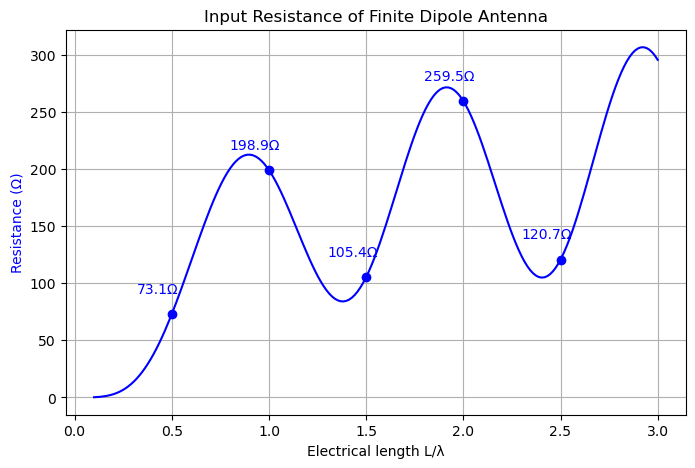

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Free-space impedance
eta0 = 376.730313668

# Input impedance of thin dipole (approximation using induced EMF method)
def dipole_impedance(lmbd_ratio):
    L = lmbd_ratio * np.pi  # electrical length (beta*L/2)

    # Real part (radiation resistance)
    Rrad = (eta0 / (2*np.pi)) * quad(lambda th: (np.cos(L*np.cos(th)) - np.cos(L))**2 / (np.sin(th)**2) * np.sin(th), 0, np.pi)[0]

    # Imag part (reactance) from integral form
    Xin = (eta0 / (2*np.pi)) * quad(lambda th: (np.cos(L*np.cos(th)) - np.cos(L)) * np.sin(L*np.cos(th)) / (np.sin(th)**2) * np.sin(th), 0, np.pi)[0]

    return Rrad, Xin

# Sweep values
Lvals = np.linspace(0.1, 3.0, 200)
Rvals, Xvals = [], []
for L in Lvals:
    R, X = dipole_impedance(L)
    Rvals.append(R)
    Xvals.append(X)

# Plot resistance and reactance
fig, ax1 = plt.subplots(figsize=(8,5))
#ax2 = ax1.twinx()

ax1.plot(Lvals, Rvals, 'b', label="Resistance (Ω)")
#ax2.plot(Lvals, Xvals, 'r', label="Reactance (Ω)")

# Highlight specific lengths with numerical values
highlight_points = [0.5, 1.0, 1.5, 2.0, 2.5]
for hl in highlight_points:
    R, X = dipole_impedance(hl)
    ax1.plot(hl, R, 'bo')
    ax2.plot(hl, X, 'ro')
    ax1.annotate(f"{R:.1f}Ω", (hl, R), textcoords="offset points", xytext=(-10,15), ha='center', color='b')
#    ax2.annotate(f"{X/1e-14:.1f} x 1e-14 Ω", (hl, X), textcoords="offset points", xytext=(0,-15), ha='center', color='r')

ax1.set_xlabel("Electrical length L/λ")
ax1.set_ylabel("Resistance (Ω)", color='b')
#ax2.set_ylabel("Reactance (Ω)", color='r')
ax1.grid(True)
plt.title("Input Resistance of Finite Dipole Antenna")
plt.show()

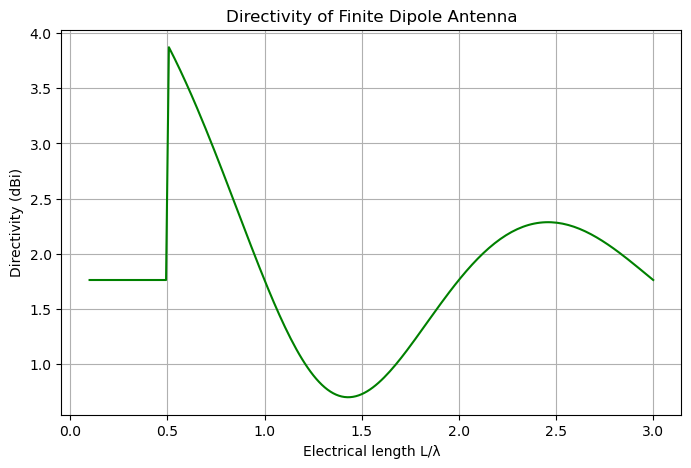

In [19]:
import numpy as np
import matplotlib.pyplot as plt


# Free-space impedance and constants
eta0 = 376.730313668


# Function to compute directivity of a thin dipole using approximate formula
def dipole_directivity(L_lambda):
# For short dipoles (L << lambda)
    if L_lambda <= 0.5:
        D = 1.5 # linear scale
    else:
    # Approximation formula for longer dipoles
    # D = 1.5*(1 + sin(beta*L)/(beta*L)) (common empirical approximation)
        beta_L = L_lambda * np.pi
        D = 1.5 * (1 + np.sin(beta_L) / beta_L)
    return 10 * np.log10(D) # convert to dBi


# Sweep electrical length
Lvals = np.linspace(0.1, 3.0, 200)
Dvals = [dipole_directivity(L) for L in Lvals]


# Plot
plt.figure(figsize=(8,5))
plt.plot(Lvals, Dvals, 'g', label='Directivity (dBi)')
plt.xlabel('Electrical length L/λ')
plt.ylabel('Directivity (dBi)')
plt.title('Directivity of Finite Dipole Antenna')
plt.grid(True)
plt.show()